In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))
sys.path.insert(0, str(Path("../..").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    BANDS_PATH,
    N_BURNIN,
    N_FFT,
    _neural_trial_job,
    amplitude_profiles,
    compute_psd_matrix,
)
from neural_correlates import (
    NOTEBOOK_GITHUB_URL,
    make_neural_correlates_figure,
)

In [2]:
# ── Neural recording trial ────────────────────────────────────────────────────
AMPLITUDE = 0.4  # sinusoidal amplitude (matches Experiment 1)
OFFSET = 0.5  # DC offset
T_TRIAL = 1024  # recording steps (power of 2; last N_FFT samples used for PSD)
N_SEEDS = 1  # seeds for PSD averaging

# ── Figure ────────────────────────────────────────────────────────────────────
# shoulder+, shoulder-, elbow+, elbow- — distinct from estimator/controller palettes
MUSCLE_COLOURS = ["#e377c2", "#7f7f7f", "#bcbd22", "#e34a33"]

In [3]:
# ── Load selection frequencies from Experiment 1 ─────────────────────────────
_d = np.load(BANDS_PATH)
bands = list(zip(_d["freqs"].tolist(), _d["labels"].tolist(), _d["colours"].tolist()))

print("Selection frequencies (loaded from Experiment 1):")
for freq, label, _ in bands:
    label_clean = label.replace("$", "")
    print(
        f"  {label_clean:12s}  f* = {freq:.4f} cyc/step   omega* = {2 * np.pi * freq:.4f} rad/step"
    )

Selection frequencies (loaded from Experiment 1):
  S+            f* = 0.0678 cyc/step   omega* = 0.4263 rad/step
  S-            f* = 0.1241 cyc/step   omega* = 0.7800 rad/step
  E+            f* = 0.2070 cyc/step   omega* = 1.3006 rad/step
  E-            f* = 0.3097 cyc/step   omega* = 1.9458 rad/step


In [4]:
from scipy.stats import pearsonr

# ── Neural recording simulation ─────────────────────────────────────────────
# For each selection frequency, record 16D y(t) over T_TRIAL steps with N_SEEDS
# independent Brain seeds, then compute the amplitude spectrum per neuron.
NEURAL_KW = dict(
    offset=OFFSET,
    amplitude=AMPLITUDE,
    t_trial=T_TRIAL,
    t_burnin=N_BURNIN,
)

neural_jobs = [
    (bi, si, float(freq), 1.0, 0.0, si + 1)  # seed = si+1; seed 0 reserved for sweep
    for bi, (freq, _, _) in enumerate(bands)
    for si in range(N_SEEDS)
]
print(f"{len(neural_jobs)} trials  (4 muscles × {N_SEEDS} seeds)")
print(
    f"Each trial: {N_BURNIN} burn-in + {T_TRIAL} recording steps; PSD uses last {N_FFT} samples."
)

n_y = 16
n_freq = N_FFT // 2 + 1
psd_data = np.zeros((len(bands), N_SEEDS, n_freq, n_y))
freqs = np.fft.rfftfreq(N_FFT)  # cyc/step

with tqdm(total=len(neural_jobs), desc="neural recording") as pbar:
    for bi, si, Y in Parallel(n_jobs=-1, return_as="generator_unordered")(
        delayed(_neural_trial_job)(*j, **NEURAL_KW) for j in neural_jobs
    ):
        _, psd_i = compute_psd_matrix(Y, N_FFT)
        psd_data[bi, si] = psd_i
        pbar.set_postfix(muscle=bands[bi][1].replace("$", ""), seed=si)
        pbar.update(1)

print("Simulation complete.")
print(f"psd_data shape: {psd_data.shape}  (bands × seeds × freq_bins × neurons)")
print(f"Freq resolution: {freqs[1]:.4f} cyc/step")

# ── Profile similarity ───────────────────────────────────────────────────────────────
# Pearson r between normalised amplitude profiles.  If all muscles recruit the
# same relative neural pattern, r should approach 1 for every pair.
# Expected: r > 0.95 for all pairs (profiles are essentially identical).

A = amplitude_profiles(freqs, psd_data, bands)  # (n_bands, n_y)
A_norm = A / A.mean(axis=1, keepdims=True)  # normalise per muscle

print("\nPairwise Pearson r between normalised amplitude profiles at omega_sel:")
for i in range(len(bands)):
    for j in range(i + 1, len(bands)):
        r, _ = pearsonr(A_norm[i], A_norm[j])
        li = bands[i][1].replace("$", "")
        lj = bands[j][1].replace("$", "")
        print(f"  {li:14s} vs {lj:14s}  r = {r:.4f}")
print("(r ≈ 1 across all pairs confirms a universal neural activation pattern.)")

4 trials  (4 muscles × 1 seeds)
Each trial: 500 burn-in + 1024 recording steps; PSD uses last 512 samples.


neural recording:   0%|          | 0/4 [00:00<?, ?it/s]

Simulation complete.
psd_data shape: (4, 1, 257, 16)  (bands × seeds × freq_bins × neurons)
Freq resolution: 0.0020 cyc/step

Pairwise Pearson r between normalised amplitude profiles at omega_sel:
  S+             vs S-              r = 0.9017
  S+             vs E+              r = 0.7644
  S+             vs E-              r = 0.6866
  S-             vs E+              r = 0.6695
  S-             vs E-              r = 0.6901
  E+             vs E-              r = 0.4470
(r ≈ 1 across all pairs confirms a universal neural activation pattern.)


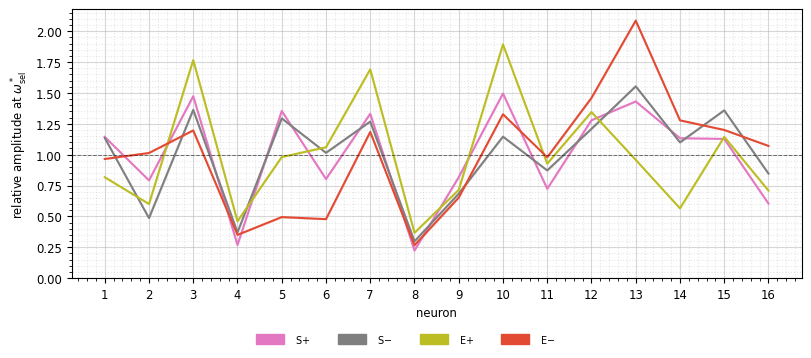

In [5]:
configure_screen()
fig = make_neural_correlates_figure(
    freqs,
    psd_data,
    bands,
    muscle_colours=MUSCLE_COLOURS,
    figsize=(8.0, 3.5),
)
apply_figure_style(fig)
plt.show()

In [6]:
FIG_WIDTH_FRAC = 0.5
FIG_HEIGHT_FRAC = 0.15
configure_pgf()
fig = make_neural_correlates_figure(
    freqs,
    psd_data,
    bands,
    muscle_colours=MUSCLE_COLOURS,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "neural_correlates.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/neural_correlates.pgf


In [7]:
caption = (
    r"Per-neuron amplitude at each of the four selection frequencies of "
    r"\autoref{fig:muscle_selection_freq_sweep}, from sustained open-loop trials "
    rf"($u_0 = {OFFSET} + {AMPLITUDE}\sin(2\pi f^* t)$, $u_1 = {OFFSET}$; "
    rf"{T_TRIAL} steps after {N_BURNIN} burn-in), each profile normalised by its "
    r"own neuron-mean (dashed line, $= 1$)."
)

save_caption(CAPTIONS_PATH / "neural_correlates.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/neural_correlates.tex
Per-neuron amplitude at each of the four selection frequencies of \autoref{fig:muscle_selection_freq_sweep}, from sustained open-loop trials ($u_0 = 0.5 + 0.4\sin(2\pi f^* t)$, $u_1 = 0.5$; 1024 steps after 500 burn-in), each profile normalised by its own neuron-mean (dashed line, $= 1$).
